# Advanced settings

- Defaults are tuned for normal use.
- Change these options only for checks or specialized investigations.

In [1]:
import matplotlib.pyplot as plt
from dark_emulator2 import DarkEmulator2 as dq2

## Mixed resolution emulator

- Lower, middle, and high resolution models are instantiated.
- Their non-linear P(k) outputs are compared.

- Resolution is controlled by particle count and box size.
- The default uses the maximum public resolution.
- `kny` is the Nyquist scale in h/Mpc.

- Emulator instances at different particle resolutions.

In [2]:
emu_LR = dq2(npart=1000)
emu_MR = dq2(npart=2000)
emu_HR = dq2(npart=3000)

print(f"N={emu_LR.npart}^3, L={emu_LR.lbox} Mpc/h, {emu_LR.kny} h/Mpc")
print(f"N={emu_MR.npart}^3, L={emu_MR.lbox} Mpc/h, {emu_MR.kny} h/Mpc")
print(f"N={emu_HR.npart}^3, L={emu_HR.lbox} Mpc/h, {emu_HR.kny} h/Mpc")

N=1000^3, L=1000 Mpc/h, 3.141592653589793 h/Mpc
N=2000^3, L=1000 Mpc/h, 6.283185307179586 h/Mpc
N=3000^3, L=1000 Mpc/h, 9.42477796076938 h/Mpc


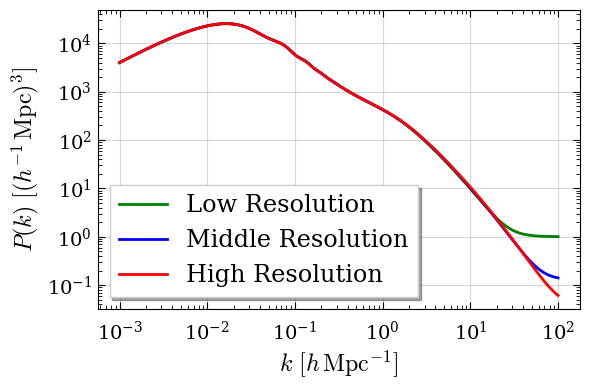

In [3]:
p = emu_HR.param.fid_param

fig = plt.figure(figsize=(6, 4))
plt.plot(*emu_LR.get_pk(p), "-", lw=2, c="green", label="Low Resolution")
plt.plot(*emu_MR.get_pk(p), "-", lw=2, c="blue", label="Middle Resolution")
plt.plot(*emu_HR.get_pk(p), "-", lw=2, c="red", label="High Resolution")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

## Shot-noise reduction

- High-k shot noise can affect derived ξ(r) and C(ℓ).
- The default suppression is tuned for smooth high-k behavior.
- The example below changes `reduce_shotnoise_method` for comparison.

In [4]:
emu = dq2()
p = emu.param.get_fid_param()

print("pk0 ", emu.reduce_shotnoise)
k0, pk0 = emu.get_pk(p, zred=3)

emu.reduce_shotnoise = True
print(emu.reduce_shotnoise)
print("pk1 ", emu.reduce_shotnoise, emu.reduce_shotnoise_method)
k1, pk1 = emu.get_pk(p, zred=3)

emu.reduce_shotnoise = True
print(emu.reduce_shotnoise)
emu.reduce_shotnoise_method["factor"] = 50.0
print("pk2 ", emu.reduce_shotnoise, emu.reduce_shotnoise_method)
k2, pk2 = emu.get_pk(p, zred=3)

emu.reduce_shotnoise = True
emu.reduce_shotnoise_method["factor"] = 5.0
print("pk3 ", emu.reduce_shotnoise, emu.reduce_shotnoise_method)
k3, pk3 = emu.get_pk(p, zred=3)

emu.reduce_shotnoise = True
emu.reduce_shotnoise_method["type"] = "grad"
emu.reduce_shotnoise_method["base"] = 10.0
emu.reduce_shotnoise_method["factor"] = -1.0
print("pk4 ", emu.reduce_shotnoise, emu.reduce_shotnoise_method)
k4, pk4 = emu.get_pk(p, zred=3)

pk0  False
True
pk1  True {'type': 'pshot', 'base': 0.037037037037037035, 'factor': 10.0}
True
pk2  True {'type': 'pshot', 'base': 0.037037037037037035, 'factor': 50.0}
pk3  True {'type': 'pshot', 'base': 0.037037037037037035, 'factor': 5.0}
pk4  True {'type': 'grad', 'base': 10.0, 'factor': -1.0}


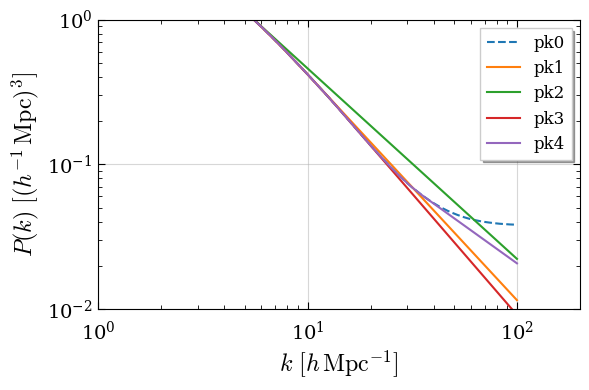

In [5]:
fig = plt.figure(figsize=(6, 4))
plt.plot(k0, pk0, "--", label="pk0")
plt.plot(k1, pk1, "-", label="pk1")
plt.plot(k2, pk2, "-", label="pk2")
plt.plot(k3, pk3, "-", label="pk3")
plt.plot(k4, pk4, "-", label="pk4")
plt.legend(fontsize="large")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1,200)
plt.ylim(1e-2,1)
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()